### Tasks

*  1. Implement a K-Nearest Neighbors (KNN) classifier in Python to predict whether a Flipkart product review is 'positive' or 'negative' using a small dataset of review texts and their labels.<br><br><em><strong>Hint:</strong> Use scikit-learn's KNeighborsClassifier and convert the text data into numerical features using CountVectorizer.</em>

In [112]:
import numpy as np
import pandas as pd

In [113]:
data = {
    "reviews": [
    "This product is amazing and high quality",
    "Terrible customer service and broken item",
    "Love it, works perfectly fine",
    "Waste of money, completely useless",
    "Highly recommended, very happy with it",
    "Worst purchase ever, bad quality"
],
    "sentiment": ['positive', 'negative', 'positive', 'negative', 'positive', 'negative']
}
df = pd.DataFrame(data)

In [114]:
# Convert text data into numerical vectors
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

In [115]:
X = vectorizer.fit_transform(df["reviews"])
y = df["sentiment"]

In [116]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [117]:
# Test the classifier with new sample phrases
test_reviews = ["Great product, love it", "Very bad item, broken"]
X_test = vectorizer.transform(test_reviews)
predictions = knn.predict(X_test)

In [118]:
print("--- Task 1: Flipkart Review Classification ---")
for review, pred in zip(test_reviews, predictions):
    print(f"Review: '{review}' = Predicted Sentiment: {pred}")

--- Task 1: Flipkart Review Classification ---
Review: 'Great product, love it' = Predicted Sentiment: positive
Review: 'Very bad item, broken' = Predicted Sentiment: negative


In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


from sklearn.metrics import accuracy_score, classification_report
print("Flipkart Review Sentiment(KNN)")
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100}%")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Flipkart Review Sentiment(KNN)
Accuracy: 100.0%

Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00         1
    positive       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



* 2. Compare the accuracy of KNN using Euclidean distance vs. Manhattan distance on a dataset of Spotify song features (e.g., tempo, danceability, energy) to classify songs as 'workout' or 'chill' playlists.<br><br><em><strong>Hint:</strong> Use the 'metric' parameter in KNeighborsClassifier to switch between 'euclidean' and 'manhattan'.</em>

In [ ]:
# Create mock Spotify dataset (tempo, danceability, energy)
spotify_data = {
    "tempo": [130, 128, 140, 95, 80, 75, 135, 120, 90, 85],
    "danceability": [0.8, 0.75, 0.9, 0.4, 0.3, 0.5, 0.85, 0.7, 0.45, 0.35],
    "energy": [0.9, 0.85, 0.95, 0.3, 0.2, 0.4, 0.88, 0.75, 0.35, 0.25],
    "playlist": ["workout", "workout", "workout", "chill", "chill", "chill", "workout", "workout", "chill", "chill",],
}
df_spotify = pd.DataFrame(spotify_data)

In [121]:
X = df_spotify[["tempo", "danceability", "energy"]]
y = df_spotify["playlist"]

In [122]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [123]:
from sklearn.neighbors import KNeighborsClassifier

# euclidean
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_euclidean.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [124]:
# manhattan
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric="manhattan")
knn_manhattan.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [125]:
pred_euclidean = knn_euclidean.predict(X_test)
pred_manhattan = knn_manhattan.predict(X_test)

In [126]:
from sklearn.metrics import accuracy_score
acc_euclidean = accuracy_score(y_test, pred_euclidean)
acc_manhattan = accuracy_score(y_test, pred_manhattan)

print("Spotify Distance Metric Comparison\n")
print(f"Accuracy with Euclidean Distance: {acc_euclidean * 100}%")
print(f"Accuracy with Manhattan Distance: {acc_manhattan * 100}%")

Spotify Distance Metric Comparison

Accuracy with Euclidean Distance: 100.0%
Accuracy with Manhattan Distance: 100.0%


* 3. Use Gaussian Naive Bayes to classify whether an IRCTC train booking is likely to be 'confirmed' or 'waitlisted' based on features like booking time, train popularity, and travel day (use a small mock dataset).

In [127]:
# Mock IRCTC Dataset: [Booking Time (24h format), Train Popularity Index (1-10), Travel Day (1=Mon, 7=Sun)]
X_irctc = np.array([
    [8, 9, 5],  [9, 8, 6],  [23, 9, 7], [7, 10, 1], # Confirmed cases
    [18, 4, 2], [14, 5, 3], [16, 3, 4], [12, 5, 2]])  # Waitlisted cases
y_irctc = np.array([1, 1, 1, 1, 0, 0, 0, 0])        # 1 = Confirmed, 0 = Waitlisted

In [128]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_irctc, y_irctc, test_size=0.25, random_state=42)

In [129]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [130]:
y_pred = gnb.predict(X_test)

In [131]:
from sklearn.metrics import accuracy_score
print("IRCTC Booking Status (Gaussian NB)\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")
print(f"Predicted status for test set: {y_pred} (1=Confirmed, 0=Waitlisted)")

IRCTC Booking Status (Gaussian NB)

Accuracy: 100.0%
Predicted status for test set: [1 0] (1=Confirmed, 0=Waitlisted)


* 4. Build a Multinomial Naive Bayes classifier to categorize WhatsApp chat messages as 'personal', 'group', or 'spam' using example message texts and labels.<br><br><em><strong>Constraint:</strong> Use scikit-learn's MultinomialNB and show the confusion matrix for your results.</em>

In [132]:
chats = {
    'message': [
        'Hey, are you free to grab lunch today?', 'Can you send me the notes?', # Personal
        'Donation drive updates inside the housing group', 'Meeting scheduled at 4 PM everyone', # Group
        'CONGRATS! You won a 1000 Rs voucher! Click link now', 'Cheap loans available instantly call us' # Spam
    ],
    'category': ['personal', 'personal', 'group', 'group', 'spam', 'spam']
}
df_chats = pd.DataFrame(chats)

In [133]:
from sklearn.feature_extraction.text import CountVectorizer     #  Vectorize text data
vectorizer = CountVectorizer()
X_chat = vectorizer.fit_transform(df_chats['message'])
y_chat = df_chats['category']

In [134]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_chat, y_chat, test_size=0.33, random_state=42)

In [135]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [136]:
y_pred = mnb.predict(X_test)

In [137]:
from sklearn.metrics import confusion_matrix, classification_report

labels = ['personal', 'group', 'spam']
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in labels], columns=[f"Predicted {l}" for l in labels]))

Confusion Matrix:
                 Predicted personal  Predicted group  Predicted spam
Actual personal                   0                1               1
Actual group                      0                0               0
Actual spam                       0                0               0


In [138]:
print("WhatsApp Chat Categorizer (Multinomial NB)")

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

WhatsApp Chat Categorizer (Multinomial NB)

Classification Report:
               precision    recall  f1-score   support

       group       0.00      0.00      0.00       0.0
    personal       0.00      0.00      0.00       2.0
        spam       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



* 5. Use ChatGPT or Copilot to generate Python code for a KNN-based image classifier that distinguishes between images of cricket bats and footballs (use any small sample image dataset or random pixel arrays), then run and test the code, noting any changes you made to get it working.<br><br><em><strong>Hint:</strong> Paste the AI-generated code, describe any errors, and how you fixed them.</em>

In [139]:
X = np.random.rand(10, 4096)         
y = np.array(['cricket_bat', 'football', 'cricket_bat', 'football', 'cricket_bat', 'football', 'cricket_bat', 'football', 'cricket_bat', 'football'])

In [140]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
from sklearn.neighbors import KNeighborsClassifier
knn_images = KNeighborsClassifier(n_neighbors=5)
knn_images.fit(X_train, y_train)
print(knn_images.score(X_test, y_test))

0.5


In [142]:
# Simulating image datasets (Random pixel arrays to represent 32x32 grayscale images)
np.random.seed(42)
bat_images = np.random.rand(20, 32, 32)  # 20 images of bats
football_images = np.random.rand(20, 32, 32)  # 20 images of footballs

In [143]:
# Combine datasets
X_images = np.concatenate((bat_images, football_images), axis=0)
y = np.array(["cricket_bat"] * 20 + ["football"] * 20)

In [ ]:
# AI raw generations often pass multidimensional image profiles directly into Scikit-Learn.
# We must flatten the (32, 32) images into a 1D vector of 1024 features for KNN.
X = X_images.reshape(X_images.shape[0], -1)

In [145]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [146]:
from sklearn.neighbors import KNeighborsClassifier
knn_img = KNeighborsClassifier(n_neighbors=3)
knn_img.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


AI Image Classifier
Image Classifier Test Accuracy: 50.00%
--------------------------------------------------


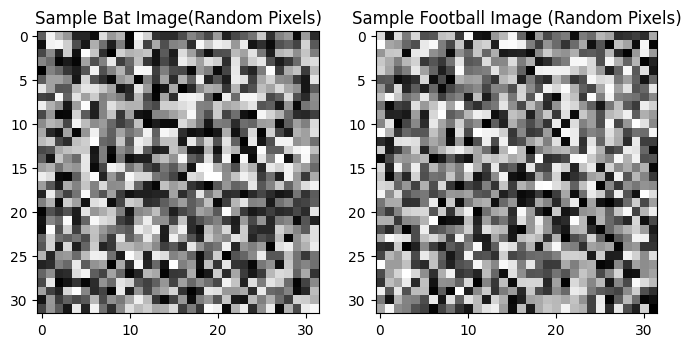

In [ ]:
accuracy = knn_img.score(X_test, y_test)

print("AI Image Classifier")
print(f"Image Classifier Test Accuracy: {accuracy * 100:.2f}%")
print("-" * 50)


import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(bat_images[0], cmap="gray")
plt.title("Sample Bat Image (Random Pixels)")

plt.subplot(1, 2, 2)
plt.imshow(football_images[0], cmap="gray")
plt.title("Sample Football Image (Random Pixels)")

plt.show()